In [48]:
import pandas as pd
import numpy as np
df = pd.read_csv("/Users/bujjamma/Downloads/project_datasets/covid19_patient_symptoms_diagnosis.csv")
print(df)

      patient_id  age  gender  fever  dry_cough  sore_throat  fatigue  \
0              1   52    Male      1          0            1        1   
1              2   15    Male      0          0            0        1   
2              3   72    Male      1          0            1        0   
3              4   61  Female      0          0            1        1   
4              5   21  Female      1          1            0        0   
...          ...  ...     ...    ...        ...          ...      ...   
4995        4996   89  Female      0          1            1        0   
4996        4997   62    Male      1          1            0        0   
4997        4998   13  Female      0          1            1        1   
4998        4999   81  Female      0          0            1        1   
4999        5000    6    Male      0          1            0        0   

      headache  shortness_of_breath  loss_of_smell  loss_of_taste  \
0            0                    0              0    

In [53]:
print(df.shape)
print(df.columns)
print(df.head())
print(df.info())

(5000, 18)
Index(['patient_id', 'age', 'gender', 'fever', 'dry_cough', 'sore_throat',
       'fatigue', 'headache', 'shortness_of_breath', 'loss_of_smell',
       'loss_of_taste', 'oxygen_level', 'body_temperature', 'comorbidity',
       'travel_history', 'contact_with_patient', 'chest_pain', 'covid_result'],
      dtype='str')
   patient_id  age  gender  fever  dry_cough  sore_throat  fatigue  headache  \
0           1   52    Male      1          0            1        1         0   
1           2   15    Male      0          0            0        1         1   
2           3   72    Male      1          0            1        0         0   
3           4   61  Female      0          0            1        1         1   
4           5   21  Female      1          1            0        0         0   

   shortness_of_breath  loss_of_smell  loss_of_taste  oxygen_level  \
0                    0              0              0            98   
1                    0              0            

In [4]:
print(df.isnull().sum())

patient_id                 0
age                        0
gender                     0
fever                      0
dry_cough                  0
sore_throat                0
fatigue                    0
headache                   0
shortness_of_breath        0
loss_of_smell              0
loss_of_taste              0
oxygen_level               0
body_temperature           0
comorbidity             2725
travel_history             0
contact_with_patient       0
chest_pain                 0
covid_result               0
dtype: int64


In [5]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool


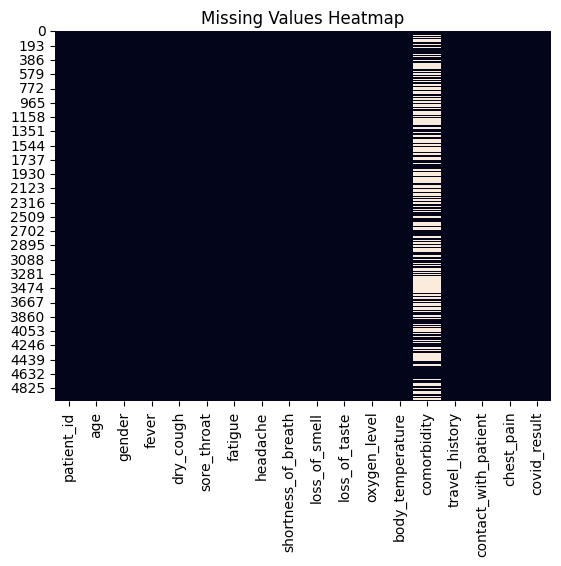

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [60]:
for x in df.index:
    if pd.isnull(df.loc[x, 'comorbidity']):
        df.loc[x, 'comorbidity'] = 'No Chronic Disease'

In [56]:
print(df.isnull().sum())

patient_id              0
age                     0
gender                  0
fever                   0
dry_cough               0
sore_throat             0
fatigue                 0
headache                0
shortness_of_breath     0
loss_of_smell           0
loss_of_taste           0
oxygen_level            0
body_temperature        0
comorbidity             0
travel_history          0
contact_with_patient    0
chest_pain              0
covid_result            0
dtype: int64


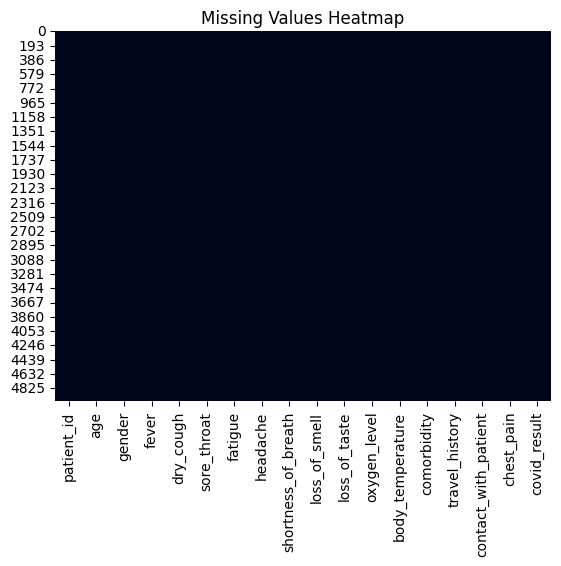

In [9]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [61]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   fever                 5000 non-null   int64  
 4   dry_cough             5000 non-null   int64  
 5   sore_throat           5000 non-null   int64  
 6   fatigue               5000 non-null   int64  
 7   headache              5000 non-null   int64  
 8   shortness_of_breath   5000 non-null   int64  
 9   loss_of_smell         5000 non-null   int64  
 10  loss_of_taste         5000 non-null   int64  
 11  oxygen_level          5000 non-null   int64  
 12  body_temperature      5000 non-null   float64
 13  comorbidity           5000 non-null   str    
 14  travel_history        5000 non-null   int64  
 15  contact_with_patient  5000 non-n

In [64]:
print(df.dtypes)


patient_id                int64
age                       int64
gender                      str
fever                     int64
dry_cough                 int64
sore_throat               int64
fatigue                   int64
headache                  int64
shortness_of_breath       int64
loss_of_smell             int64
loss_of_taste             int64
oxygen_level              int64
body_temperature        float64
comorbidity                 str
travel_history            int64
contact_with_patient      int64
chest_pain                int64
covid_result              int64
dtype: object


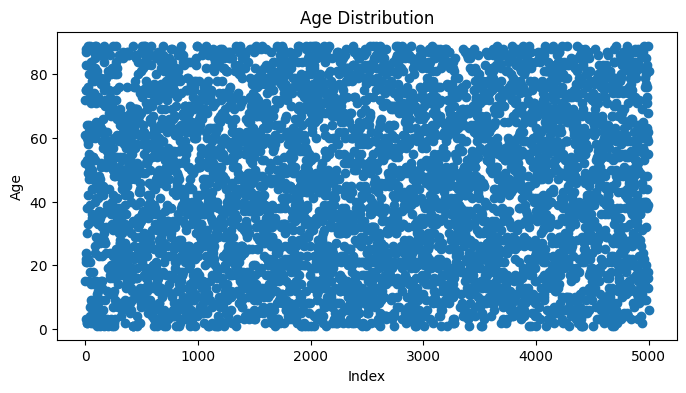

In [65]:
plt.figure(figsize=(8,4))
plt.scatter(range(len(df['age'])), df['age'])
plt.title("Age Distribution")
plt.xlabel("Index")
plt.ylabel("Age")
plt.show()

In [82]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower) | (df['age'] > upper)]

print(outliers)

Empty DataFrame
Columns: [patient_id, age, gender, fever, dry_cough, sore_throat, fatigue, headache, shortness_of_breath, loss_of_smell, loss_of_taste, oxygen_level, body_temperature, comorbidity, travel_history, contact_with_patient, chest_pain, covid_result, zscore]
Index: []


<Axes: >

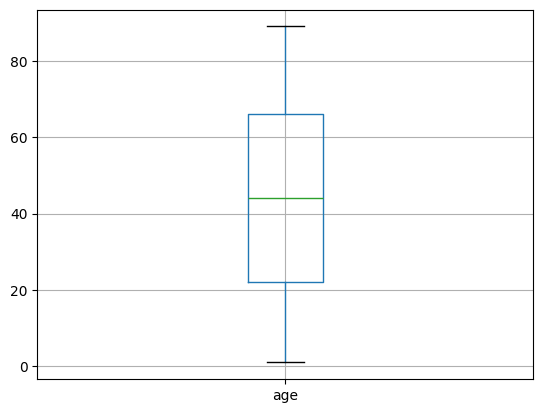

In [84]:
df.boxplot(column = 'age')

<Axes: >

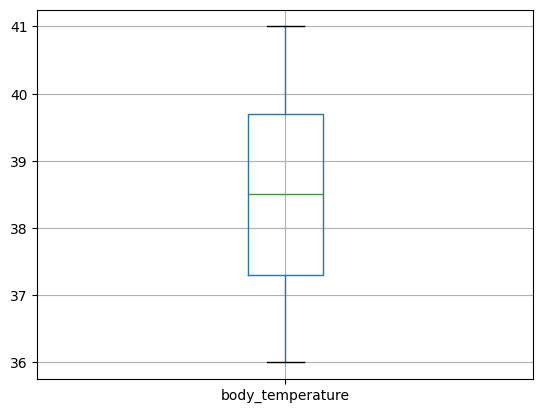

In [86]:
df.boxplot(column = 'body_temperature')

<Axes: >

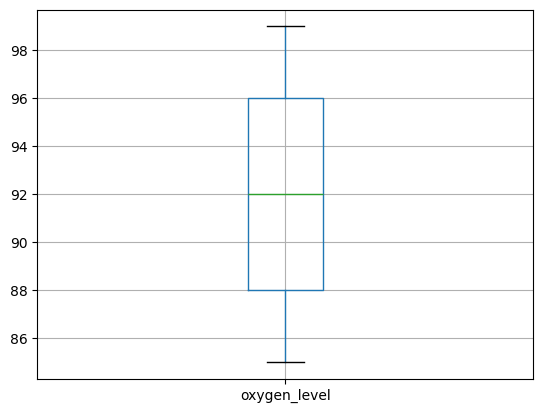

In [87]:
df.boxplot(column = 'oxygen_level')

In [94]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_upper = df[df['age'] > upper_bound]
outliers_lower = df[df['age'] < lower_bound]

print(outliers_upper)
print(outliers_lower)

Empty DataFrame
Columns: [patient_id, age, gender, fever, dry_cough, sore_throat, fatigue, headache, shortness_of_breath, loss_of_smell, loss_of_taste, oxygen_level, body_temperature, comorbidity, travel_history, contact_with_patient, chest_pain, covid_result, zscore]
Index: []
Empty DataFrame
Columns: [patient_id, age, gender, fever, dry_cough, sore_throat, fatigue, headache, shortness_of_breath, loss_of_smell, loss_of_taste, oxygen_level, body_temperature, comorbidity, travel_history, contact_with_patient, chest_pain, covid_result, zscore]
Index: []


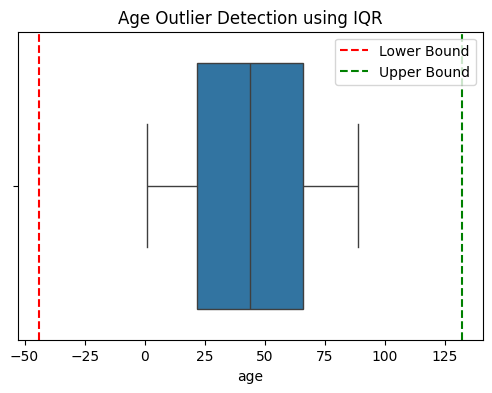

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(x=df['age'])

plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')

plt.title("Age Outlier Detection using IQR")
plt.legend()

plt.show()